# Notebook 03 — Dropout Timing & Withdrawal Patterns

**Project:** Programme Health Intelligence: A Learning Analytics Case Study  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Author:** Megha Sinha  
**Date:** June 2026

---

## Objective

This notebook investigates *when* students withdraw from their programmes,
addressing Business Question 3:

*"At what point in a programme do students typically withdraw? Is there
a consistent critical window? Do withdrawal patterns differ by module
or prior attempt history?"*

### What We Will Cover
1. Load and prepare registration and student data
2. Analyse overall withdrawal timing distribution
3. Identify critical withdrawal windows
4. Compare withdrawal timing across modules
5. Examine prior attempt history and withdrawal timing
6. Identify early dropouts — students who withdrew before any assessment
7. Produce intervention timing recommendations

---

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Global Style Settings ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     11,
    'axes.labelcolor':    '#2C2C2C',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         130,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight'
})

sns.set_theme(style='whitegrid', rc={
    'grid.color':     '#E5E5E5',
    'grid.linewidth': 0.7
})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Business Colour Palette ────────────────────────────────────────
outcome_colours = {
    'Pass':        '#2C5F8A',
    'Distinction': '#1A3A5C',
    'Fail':        '#C0392B',
    'Withdrawn':   '#7F8C8D'
}

module_colours = {
    'AAA': '#1A3A5C',
    'BBB': '#2C5F8A',
    'CCC': '#C0392B',
    'DDD': '#7F8C8D',
    'EEE': '#2E86AB',
    'FFF': '#A23B72',
    'GGG': '#F18F01'
}

def add_bar_labels(ax, fmt='{:.0f}', padding=2,
                   fontsize=10, color='#2C2C2C'):
    for bar in ax.patches:
        val = bar.get_height()
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + padding,
                fmt.format(val),
                ha='center', va='bottom',
                fontsize=fontsize, color=color,
                fontweight='bold'
            )

print("Global styles and palette loaded successfully")

Global styles and palette loaded successfully


---

## 2. Load Cleaned Data

In [2]:
processed_path = '../data/processed/'

student_reg  = pd.read_csv(processed_path + 'studentRegistration_clean.csv')
student_info = pd.read_csv(processed_path + 'studentInfo_clean.csv')
student_assessment = pd.read_csv(processed_path + 'studentAssessment_clean.csv')
courses      = pd.read_csv(processed_path + 'courses_clean.csv')

print("Files loaded successfully\n")
print(f"  student_reg:        {student_reg.shape[0]:,} rows")
print(f"  student_info:       {student_info.shape[0]:,} rows")
print(f"  student_assessment: {student_assessment.shape[0]:,} rows")
print(f"  courses:            {courses.shape[0]:,} rows")

Files loaded successfully

  student_reg:        32,548 rows
  student_info:       32,593 rows
  student_assessment: 173,739 rows
  courses:            22 rows


---

## 3. Prepare Withdrawal Data

Isolating withdrawn students and merging with student demographics
and course length data to enable timing and demographic analysis.

In [10]:
# Merge registration with student info and course length
withdrawal_data = student_reg.merge(
    student_info[['id_student', 'code_module', 'code_presentation',
                  'gender', 'age_band', 'imd_band', 'disability',
                  'num_of_prev_attempts', 'highest_education',
                  'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
).merge(
    courses[['code_module', 'code_presentation',
             'module_presentation_length']],
    on=['code_module', 'code_presentation'],
    how='left'
)

# Isolate withdrawn students only
withdrawn = withdrawal_data[
    withdrawal_data['date_unregistration'].notna()].copy()

# Separate pre-module and post-registration withdrawals
pre_module = withdrawn[withdrawn['date_unregistration'] < 0]
post_registration = withdrawn[withdrawn['date_unregistration'] >= 0].copy()

print(f"Total withdrawals:                      {len(withdrawn):,}")
print(f"Pre-module withdrawals (before day 0):  {len(pre_module):,} ({len(pre_module)/len(withdrawn)*100:.1f}%)")
print(f"Post-registration withdrawals (day 0+): {len(post_registration):,} ({len(post_registration)/len(withdrawn)*100:.1f}%)")

# Calculate withdrawal point as % of module length
post_registration['withdrawal_pct'] = (
    post_registration['date_unregistration'] /
    post_registration['module_presentation_length'] * 100
).round(1)

# Classify withdrawal timing
post_registration['withdrawal_stage'] = pd.cut(
    post_registration['withdrawal_pct'],
    bins=[0, 25, 50, 75, 100, float('inf')],
    labels=['Very Early (0-25%)', 'Early (25-50%)',
            'Mid (50-75%)', 'Late (75-100%)', 'Post-module'],
    include_lowest=True #to include day 0 
)

print(f"\nWithdrawal stage distribution (post-registration only):")
print(post_registration['withdrawal_stage'].value_counts().sort_index())

print(f"\nWithdrawal timing stats (days, post-registration):")
print(post_registration['date_unregistration'].describe().round(1))

# Check unaccounted withdrawals
unaccounted = post_registration['withdrawal_stage'].isna().sum()
print(f"withdrawal_pct > 100: {(post_registration['withdrawal_pct'] > 100).sum():,}") #students who withdrew after end date


Total withdrawals:                      10,033
Pre-module withdrawals (before day 0):  2,643 (26.3%)
Post-registration withdrawals (day 0+): 7,390 (73.7%)

Withdrawal stage distribution (post-registration only):
Very Early (0-25%)    3664
Early (25-50%)        1647
Mid (50-75%)          1441
Late (75-100%)         637
Post-module              1
Name: withdrawal_stage, dtype: int64

Withdrawal timing stats (days, post-registration):
count   7390.00
mean      82.00
std       68.50
min        0.00
25%       17.00
50%       66.00
75%      137.00
max      444.00
Name: date_unregistration, dtype: float64
withdrawal_pct > 100: 1


---

### 3.1 Data Quality Note

Withdrawal timing is expressed as days relative to module start (day 0).
Negative values indicate students who withdrew before the module began —
these are treated separately as **pre-module withdrawals** and excluded
from timing analysis where relevant.

---

## 4. Withdrawal Timing — Visualisation

Visualising when withdrawals occur across the module timeline to
identify the critical intervention window clearly.

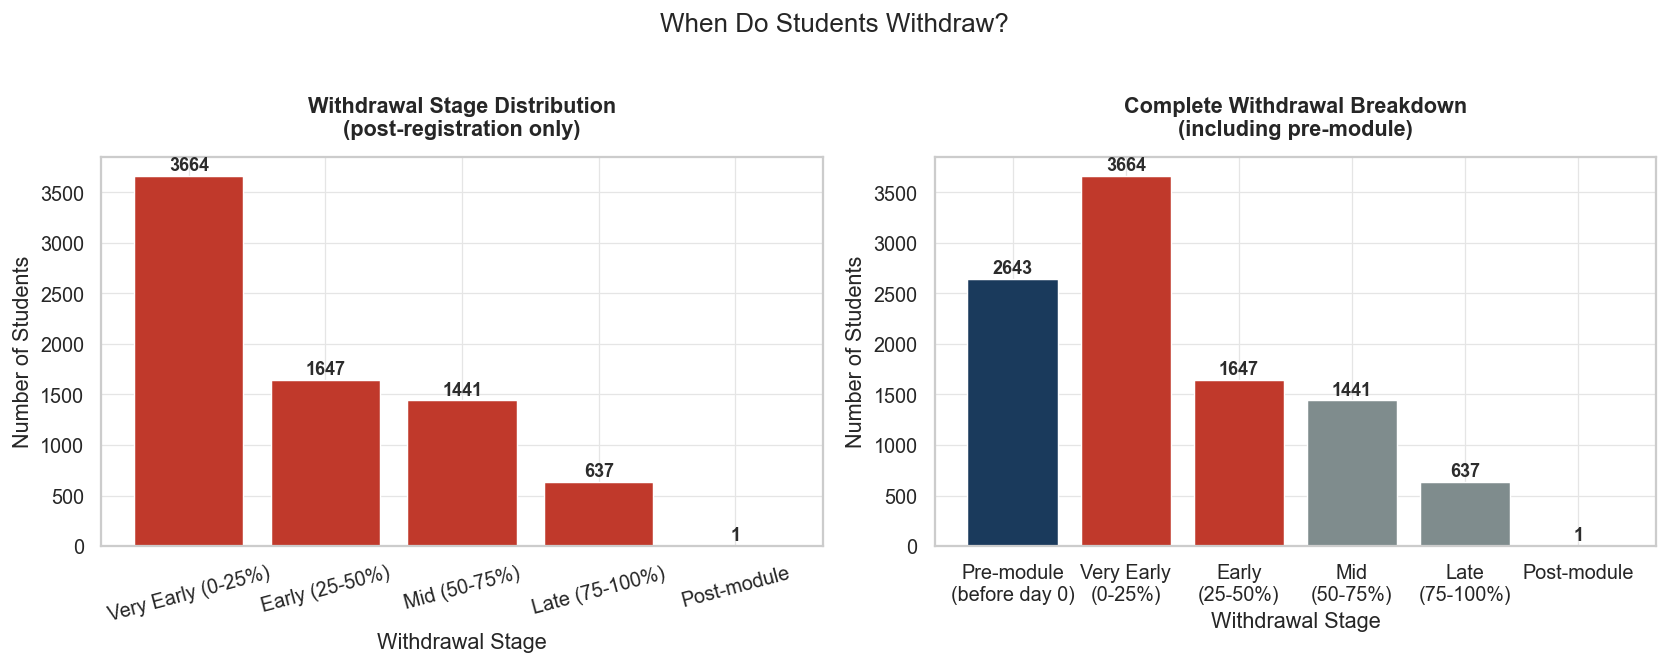

Chart saved to images/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — withdrawal stage distribution
stage_counts = post_registration['withdrawal_stage'].value_counts().sort_index()
axes[0].bar(stage_counts.index, stage_counts.values,
            color='#C0392B', edgecolor='white', linewidth=0.8)
axes[0].set_title('Withdrawal Stage Distribution\n(post-registration only)')
axes[0].set_xlabel('Withdrawal Stage')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=15)
add_bar_labels(axes[0], padding=15)

# Right — full withdrawal breakdown including pre-module
labels = ['Pre-module\n(before day 0)', 'Very Early\n(0-25%)',
          'Early\n(25-50%)', 'Mid\n(50-75%)',
          'Late\n(75-100%)', 'Post-module']
values = [len(pre_module), *stage_counts.values]
colours = ['#1A3A5C', '#C0392B', '#C0392B', '#7F8C8D',
           '#7F8C8D', '#7F8C8D']

axes[1].bar(labels, values, color=colours,
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Complete Withdrawal Breakdown\n(including pre-module)')
axes[1].set_xlabel('Withdrawal Stage')
axes[1].set_ylabel('Number of Students')
add_bar_labels(axes[1], padding=15)

fig.suptitle('When Do Students Withdraw?', y=1.02)
plt.tight_layout()
plt.savefig('../images/08_withdrawal_timing.png')
plt.show()
print("Chart saved to images/")

---

## 5. Withdrawal Timing by Module

Does the critical early withdrawal window apply equally across all
modules — or do some modules lose students at different points?

In [12]:
# Withdrawal stage by module
module_withdrawal = (
    post_registration
    .groupby(['code_module', 'withdrawal_stage'])
    .size()
    .unstack(fill_value=0)
)

# Reorder columns
stage_order = ['Very Early (0-25%)', 'Early (25-50%)',
               'Mid (50-75%)', 'Late (75-100%)', 'Post-module']
module_withdrawal = module_withdrawal.reindex(
    columns=stage_order, fill_value=0)

# Add percentage of very early withdrawals per module
module_withdrawal['total'] = module_withdrawal.sum(axis=1)
module_withdrawal['very_early_pct'] = (
    module_withdrawal['Very Early (0-25%)'] /
    module_withdrawal['total'] * 100
).round(1)

print("=== WITHDRAWAL TIMING BY MODULE ===\n")
print(module_withdrawal.sort_values('very_early_pct', ascending=False))

=== WITHDRAWAL TIMING BY MODULE ===

withdrawal_stage  Very Early (0-25%)  Early (25-50%)  Mid (50-75%)  \
code_module                                                          
BBB                              845             294           255   
CCC                              780             327           270   
EEE                              280             125            96   
FFF                              897             444           340   
DDD                              761             370           384   
GGG                               71              66            61   
AAA                               30              21            35   

withdrawal_stage  Late (75-100%)  Post-module  total  very_early_pct  
code_module                                                           
BBB                          126            0   1520           55.60  
CCC                          107            0   1484           52.60  
EEE                           33            0   

---

## 6. Prior Attempt History & Withdrawal Timing

Students who have previously attempted the same module may withdraw
at different points than first-time students. Understanding this
pattern helps target intervention more precisely.

In [13]:
# Prior attempts vs withdrawal stage
attempts_withdrawal = (
    post_registration
    .groupby(['num_of_prev_attempts', 'withdrawal_stage'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=stage_order, fill_value=0)
)

attempts_withdrawal['total'] = attempts_withdrawal.sum(axis=1)
attempts_withdrawal['very_early_pct'] = (
    attempts_withdrawal['Very Early (0-25%)'] /
    attempts_withdrawal['total'] * 100
).round(1)

print("=== WITHDRAWAL TIMING BY PRIOR ATTEMPTS ===\n")
print(attempts_withdrawal)

# Average withdrawal day by prior attempts
avg_withdrawal_day = (
    post_registration
    .groupby('num_of_prev_attempts')['date_unregistration']
    .agg(['mean', 'median', 'count'])
    .round(1)
)
avg_withdrawal_day.columns = ['mean_day', 'median_day', 'count']
print("\nAverage withdrawal day by prior attempts:")
print(avg_withdrawal_day)

=== WITHDRAWAL TIMING BY PRIOR ATTEMPTS ===

withdrawal_stage      Very Early (0-25%)  Early (25-50%)  Mid (50-75%)  \
num_of_prev_attempts                                                     
0                                   3160            1405          1203   
1                                    410             197           187   
2                                     68              38            39   
3                                     17               5             9   
4                                      6               1             2   
5                                      3               1             0   
6                                      0               0             1   

withdrawal_stage      Late (75-100%)  Post-module  total  very_early_pct  
num_of_prev_attempts                                                      
0                                528            1   6297           50.20  
1                                 77            0    871       

---

## 7. Early Dropouts — Withdrew Before Any Assessment

Students who withdrew without submitting a single assessment represent
the most disengaged group. Identifying their scale and module
distribution helps prioritise pre-assessment intervention.

In [15]:
# Students who submitted at least one assessment
assessed_students = set(
    zip(student_assessment['id_student'],
        student_assessment['id_assessment'])
)

# All withdrawn students
withdrawn_ids = set(zip(
    withdrawn['id_student'],
    withdrawn['code_module']
))

# Get assessments with module info
assessments = pd.read_csv(processed_path + 'assessments_clean.csv')
student_assessment_module = student_assessment.merge(
    assessments[['id_assessment', 'code_module']],
    on='id_assessment',
    how='left'
)

# Students who submitted at least one assessment per module
submitted = set(zip(
    student_assessment_module['id_student'],
    student_assessment_module['code_module']
))

# Withdrawn students with no assessment submission
withdrawn['submitted_assessment'] = withdrawn.apply(
    lambda row: (row['id_student'], row['code_module']) in submitted,
    axis=1
)

no_assessment = withdrawn[~withdrawn['submitted_assessment']]
with_assessment = withdrawn[withdrawn['submitted_assessment']]

print("=== EARLY DROPOUTS — NO ASSESSMENT SUBMITTED ===\n")
print(f"Withdrawn with no assessment:    {len(no_assessment):,} ({len(no_assessment)/len(withdrawn)*100:.1f}%)")
print(f"Withdrawn with assessment:       {len(with_assessment):,} ({len(with_assessment)/len(withdrawn)*100:.1f}%)")

print("\nEarly dropouts by module:")
print(no_assessment['code_module']
      .value_counts()
      .reset_index()
      .rename(columns={'index': 'module',
                       'code_module': 'early_dropouts'}))

=== EARLY DROPOUTS — NO ASSESSMENT SUBMITTED ===

Withdrawn with no assessment:    5,032 (50.2%)
Withdrawn with assessment:       5,001 (49.8%)

Early dropouts by module:
  module  early_dropouts
0    BBB            1433
1    FFF            1127
2    DDD             990
3    CCC             821
4    EEE             453
5    GGG             180
6    AAA              28


---

## 8. Notebook Summary

### Key Findings

| Finding | Detail |
|---|---|
| Pre-module withdrawals | 26.3% of all withdrawals occur before module start |
| Critical window | 62.8% of withdrawals happen before module halfway point |
| Median withdrawal day | Day 66 — approximately 9-10 weeks into the module |
| Most critical module | BBB — 55.6% very early withdrawal, 94.3% pre-assessment dropout |
| Most sustained problem | CCC — high very early AND sustained withdrawals throughout |
| Best performer | GGG — lowest very early rate (31.7%) and lowest overall withdrawal rate |
| Repeat attempt students | Withdraw later (median day 100) but still struggle to complete |
| Pre-assessment dropouts | 50.2% of withdrawn students never submitted any assessment |
| AAA distinction | Only 26.4% pre-assessment dropout — withdrawals are performance-driven |

### Two Distinct Withdrawal Types Identified

**Type 1 — Commitment/Onboarding Failure**
Student registers but disengages before meaningful academic participation.
Characterised by pre-module or very early withdrawal, no assessment submission.
Most prevalent in BBB and EEE.
*Intervention: Pre-module engagement, clear expectation setting, early outreach.*

**Type 2 — Performance/Sustained Struggle**
Student engages academically but withdraws after attempting assessments.
Characterised by later withdrawal timing, at least one assessment submitted.
Most prevalent in AAA and CCC.
*Intervention: Academic support, assessment feedback, targeted coaching.*

### Operational Recommendations

1. **Trigger intervention at enrolment** — 26.3% of withdrawals happen before day 0. Pre-module engagement campaigns are essential
2. **Focus first 10 weeks** — median withdrawal day is 66. The first 10 weeks are the single most critical intervention window
3. **Flag students with no assessment submission by week 4** — 50.2% of withdrawals never submit. Early academic engagement should be monitored and acted on immediately
4. **Treat BBB and EEE differently from CCC and AAA** — BBB/EEE need onboarding interventions; CCC/AAA need sustained academic support
5. **Design targeted support for repeat-attempt students** — they persist but need help overcoming specific completion barriers

### Files Produced

| File | Location |
|---|---|
| 08_withdrawal_timing.png | images/ |

### Next Steps
**Notebook 04 — Assessment Performance:** How strongly do early
assessment scores predict final outcomes — and how much warning
does the data give us?

---

*End of Notebook 03 — Dropout Timing & Withdrawal Patterns*